In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
import os

DATASET_PATH = "/kaggle/input"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sonali181234
/kaggle/input/datasets/sonali181234/brain-tumour-dataset
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Training
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Training/pituitary
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Training/notumor
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Training/meningioma
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Training/glioma
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Testing
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Testing/pituitary
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Testing/notumor
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Testing/meningioma
/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Testing/glioma


In [4]:
!pip install timm grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.1 MB/s eta 0:00:00:00:010:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 105.8 MB/s eta 0:00:0000:010:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=ea07c1edea50f3fdb939ac397fff121c8787399e002879f9fcf4579866ce5e12
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3

In [5]:
import os
import json
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [6]:
TRAIN_DIR = "/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Training"
TEST_DIR = "/kaggle/input/datasets/sonali181234/brain-tumour-dataset/Testing"

print(os.listdir(TRAIN_DIR))

['pituitary', 'notumor', 'meningioma', 'glioma']


In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [9]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(train_dataset.classes)
print(len(train_dataset))
print(len(test_dataset))

['glioma', 'meningioma', 'notumor', 'pituitary']
5600
1600


In [10]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 200MB/s]


In [11]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, 4)
)

model = model.to(device)

print(model.fc)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=4, bias=True)
)


In [20]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [24]:
optimizer = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [23]:
criterion = nn.CrossEntropyLoss()

In [25]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.2,
    patience=2
)

In [26]:
EPOCHS = 15

best_acc = 0.0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [27]:
import torch
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 15

LEARNING_RATE = 1e-4

NUM_CLASSES = 4

print("Device :", DEVICE)

Device : cuda


In [28]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [29]:
from torchvision.datasets import ImageFolder

train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

test_dataset = ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [64]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_loader))
print(len(test_loader))

175
50


In [31]:
import json

class_names = train_dataset.classes

with open("class_names.json","w") as f:
    json.dump(class_names,f)

print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


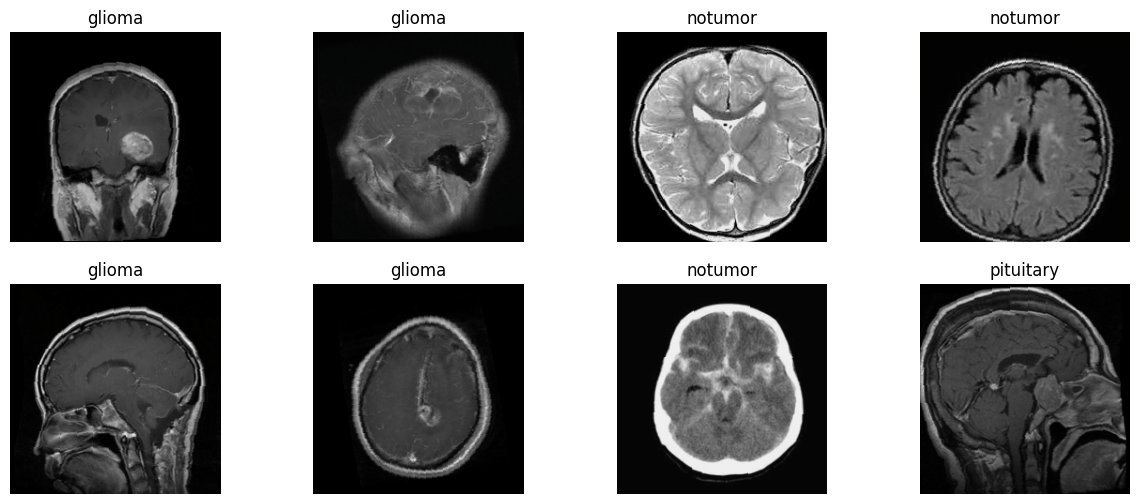

In [32]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.figure(figsize=(15,6))

for i in range(8):

    plt.subplot(2,4,i+1)

    img = images[i].permute(1,2,0).numpy()

    img = img*np.array([0.229,0.224,0.225])+np.array([0.485,0.456,0.406])

    img=np.clip(img,0,1)

    plt.imshow(img)

    plt.title(class_names[labels[i]])

    plt.axis("off")

plt.show()

In [33]:
from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

In [34]:
class EarlyStopping:

    def __init__(self, patience=5):

        self.patience = patience

        self.counter = 0

        self.best_loss = float("inf")

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss:

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.early_stop = True

In [35]:
def calculate_accuracy(outputs, labels):

    _, preds = torch.max(outputs,1)

    correct = (preds==labels).sum().item()

    return correct / labels.size(0)

In [36]:
def train_one_epoch(model,
                    loader,
                    criterion,
                    optimizer):

    model.train()

    running_loss = 0

    running_acc = 0

    for images,labels in tqdm(loader):

        images = images.to(DEVICE)

        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs,labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        running_acc += calculate_accuracy(outputs,labels)

    epoch_loss = running_loss/len(loader)

    epoch_acc = running_acc/len(loader)

    return epoch_loss,epoch_acc

In [37]:
def validate(model,
             loader,
             criterion):

    model.eval()

    running_loss = 0

    running_acc = 0

    preds=[]

    labels_list=[]

    with torch.no_grad():

        for images,labels in tqdm(loader):

            images = images.to(DEVICE)

            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs,labels)

            running_loss += loss.item()

            running_acc += calculate_accuracy(outputs,labels)

            _,prediction = torch.max(outputs,1)

            preds.extend(prediction.cpu().numpy())

            labels_list.extend(labels.cpu().numpy())

    epoch_loss = running_loss/len(loader)

    epoch_acc = running_acc/len(loader)

    return epoch_loss,epoch_acc,preds,labels_list

In [71]:
def train_model(model,
                optimizer,
                scheduler,
                criterion,
                model_name):

    best_acc = 0

    history = {

        "train_loss":[],

        "val_loss":[],

        "train_acc":[],

        "val_acc":[]

    }

    early_stopping = EarlyStopping(patience=5)

    for epoch in range(EPOCHS):

        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        train_loss,train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss,val_acc,preds,labels = validate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss : {train_loss:.4f}")

        print(f"Val Loss : {val_loss:.4f}")

        print(f"Train Acc : {train_acc:.4f}")

        print(f"Val Acc : {val_acc:.4f}")

        if val_acc > best_acc:

            best_acc = val_acc

            torch.save(
                model.state_dict(),
                f"{model_name}_best.pth"
            )

            print("Best model saved.")

        early_stopping(val_loss)

        if early_stopping.early_stop:

            print("Early stopping")

            break

    return history

In [40]:
from torchvision.models import resnet50, ResNet50_Weights

def build_resnet50():

    weights = ResNet50_Weights.DEFAULT

    model = resnet50(weights=weights)

    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, NUM_CLASSES)
    )

    return model.to(DEVICE)

In [41]:
resnet_model = build_resnet50()

print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [42]:
criterion = nn.CrossEntropyLoss()

In [43]:
optimizer = torch.optim.AdamW(
    resnet_model.fc.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

In [49]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=2
)

In [53]:
history_resnet = train_model(
    model=resnet_model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    model_name="resnet50"
)


Epoch 1/15


  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss : 0.4899
Val Loss : 0.6069
Train Acc : 0.8371
Val Acc : 0.7844
Best model saved.

Epoch 2/15


  0%|          | 0/175 [00:00<?, ?it/s]

...

  0%|          | 0/175 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7808f9fd5e40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7808f9fd5e40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/50 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7808f9fd5e40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7808f9fd5e40>  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers

    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__

     self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
     if w.is_alive():  
       ^ ^ ^^^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^^
 
  File "/usr/lib/pytho

Train Loss : 0.4419
Val Loss : 0.5679
Train Acc : 0.8505
Val Acc : 0.7994
Early stopping


In [54]:
from torchvision.models import resnet50, ResNet50_Weights

def build_resnet50():

    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, NUM_CLASSES)
    )

    return model.to(DEVICE)

In [63]:
optimizer = torch.optim.AdamW([
    {"params": resnet_model.layer4.parameters(), "lr": 1e-5},
    {"params": resnet_model.fc.parameters(), "lr": 1e-4}
], weight_decay=1e-4)

In [65]:
history_resnet = train_model(
    model=resnet_model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    model_name="resnet50"
)


Epoch 1/15


  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss : 0.4465
Val Loss : 0.5720
Train Acc : 0.8471
Val Acc : 0.7906
Best model saved.

Epoch 2/15


  0%|          | 0/175 [00:00<?, ?it/s]

...

^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


Train Loss : 0.4105
Val Loss : 0.5150
Train Acc : 0.8505
Val Acc : 0.8219
Best model saved.

Epoch 15/15


  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train Loss : 0.3961
Val Loss : 0.5292
Train Acc : 0.8614
Val Acc : 0.8150


In [66]:
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split

full_train_dataset = ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Validation should not use augmentation
val_dataset.dataset.transform = test_transform

test_dataset = ImageFolder(
    TEST_DIR,
    transform=test_transform
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

4480
1120
1600


In [67]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

140
35
50


In [68]:
from torchvision.models import resnet50, ResNet50_Weights

def build_resnet50():

    model = resnet50(weights=ResNet50_Weights.DEFAULT)

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze layer3
    for param in model.layer3.parameters():
        param.requires_grad = True

    # Unfreeze layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    num_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, NUM_CLASSES)
    )

    return model.to(DEVICE)

In [70]:
optimizer = torch.optim.AdamW(
    [
        {"params": resnet_model.layer3.parameters(), "lr": 1e-5},
        {"params": resnet_model.layer4.parameters(), "lr": 1e-5},
        {"params": resnet_model.fc.parameters(), "lr": 1e-4}
    ],
    weight_decay=1e-4
)

In [72]:
history_resnet = train_model(
    model=resnet_model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    model_name="resnet50"
)


Epoch 1/15


  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Train Loss : 0.3803
Val Loss : 0.3583
Train Acc : 0.8761
Val Acc : 0.8902
Best model saved.

Epoch 2/15


  0%|          | 0/140 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]

Train Loss : 0.3376
Val Loss : 0.3126
Train Acc : 0.8895
Val Acc : 0.9027
Best model saved.

Epoch 15/15


  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Train Loss : 0.3437
Val Loss : 0.3195
Train Acc : 0.8819
Val Acc : 0.8920


In [73]:
# Build the model
resnet_model = build_resnet50()

# Load best weights
resnet_model.load_state_dict(
    torch.load("resnet50_best.pth", map_location=DEVICE)
)

resnet_model = resnet_model.to(DEVICE)

# Test
test_loss, test_acc, preds, labels = validate(
    resnet_model,
    test_loader,
    criterion
)

print(f"Test Accuracy : {test_acc:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]

Test Accuracy : 0.8331


In [74]:
from sklearn.metrics import classification_report

print(classification_report(
    labels,
    preds,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.91      0.65      0.75       400
  meningioma       0.72      0.78      0.75       400
     notumor       0.83      0.98      0.90       400
   pituitary       0.91      0.92      0.92       400

    accuracy                           0.83      1600
   macro avg       0.84      0.83      0.83      1600
weighted avg       0.84      0.83      0.83      1600



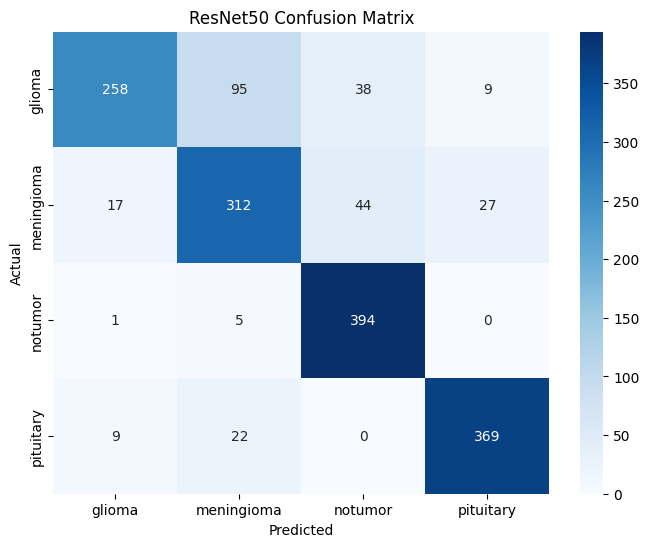

In [75]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet50 Confusion Matrix")

plt.show()

In [80]:
results = {}

results["ResNet50"] = {
    "Accuracy": test_acc
}

In [81]:
!pip install timm

In [82]:
import timm

In [96]:
import timm
import torch.nn as nn

def build_efficientnet_b3():

    model = timm.create_model(
        "efficientnet_b3",
        pretrained=True,
        num_classes=NUM_CLASSES
    )

    model = model.to(DEVICE)

    return model

In [97]:
efficientnet_model = build_efficientnet_b3()

print(efficientnet_model)

EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [99]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

In [100]:
optimizer = torch.optim.AdamW(
    efficientnet_model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

In [102]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.2,
    patience=2
)

In [103]:
history_efficientnet = train_model(
    model=efficientnet_model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    model_name="efficientnet_b3"
)


Epoch 1/15


  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Train Loss : 1.4119
Val Loss : 1.1833
Train Acc : 0.6777
Val Acc : 0.7536
Best model saved.

Epoch 2/15


  0%|          | 0/140 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]

Train Loss : 0.4516
Val Loss : 14.3500
Train Acc : 0.9884
Val Acc : 0.8616
Best model saved.

Epoch 7/15


  0%|          | 0/140 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Train Loss : 0.4467
Val Loss : 4.4687
Train Acc : 0.9873
Val Acc : 0.8482
Early stopping


In [104]:
efficientnet_model = build_efficientnet_b3()

efficientnet_model.load_state_dict(
    torch.load(
        "efficientnet_b3_best.pth",
        map_location=DEVICE
    )
)

efficientnet_model.to(DEVICE)

test_loss, test_acc, preds, labels = validate(
    efficientnet_model,
    test_loader,
    criterion
)

print(test_acc)

  0%|          | 0/50 [00:00<?, ?it/s]

0.83
